<a href="https://colab.research.google.com/github/THEMKM/GAFL_RESTORE_MKM/blob/main/RESTORE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV

# Load STATA file
df = pd.read_stata('/content/cdi_household_clean_nopii.dta', convert_categoricals= False)

column_list = df.columns[:3000].tolist()
print(column_list)

['duration', 'region', 'district', 'vill', 'village', 'community_type', 'restore_check', 'hhid_restore', 'village_restore', 'gender_restore', 'sample_restore', 'confirm_restore', 'hhid_nonrestore', 'hhid', 'any_questions', 'consent', 'consent_record', 'screen_cocoa', 'screen_sharecrop', 'audio_audit', 'resp_sex', 'respondent', 'nothead', 'nothead_oth', 'ethnicity', 'ethnicity_oth', 'language', 'language_oth', 'religion', 'lead_vill', 'lead_vill_0', 'lead_vill_1', 'lead_vill_3', 'lead_vill_4', 'lead_vill_5', 'lead_vill_6', 'lead_vill_7', 'lead_vill_8', 'lead_vill_9', 'lead_vill_10', 'lead_vill_11', 'lead_vill_12', 'lead_vill_13', 'lead_vill_97', 'lead_villo', 'prim_fem_yn', 'hhmem_size_1', 'child_check1', 'other_check', 'hhmem_size', 'hhgroup_m18', 'hhgroup_f18', 'hhgroup_m17', 'hhgroup_f17', 'hh_roster_count', 'respondent_yn_1', 'hh_relate_1', 'hh_child_1', 'hh_relate_oth_1', 'hhmem_sex_1', 'ethnicity_head_1', 'ethnicity_head_oth_1', 'hhmem_age_1', 'hhmem_born_1', 'hhmem_married_1', 'h

In [1]:
!pip install pandas numpy scikit-learn pyreadstat


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.preprocessing import LabelEncoder
import pyreadstat
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data with Smart Filtering
def load_and_filter(file_path, target_col, missing_thresh=80, var_thresh=95):
    # Load data with metadata
    df, meta = pyreadstat.read_dta(file_path)

    # Save the target column separately
    target_data = df[target_col]

    # Phase 1: Aggressive Column Filtering
    # Remove columns with > missing_thresh% missing values (except target_col)
    missing = df.drop(columns=[target_col]).isnull().mean() * 100
    cols_to_keep = missing[missing < missing_thresh].index.tolist()
    # Add back the target column
    cols_to_keep.append(target_col)
    df = df[cols_to_keep]

    # Remove zero/low variance columns (except target_col)
    nunique = df.drop(columns=[target_col]).nunique()
    cols_to_keep = nunique[(nunique > 1) & (nunique < var_thresh)].index.tolist()
    # Add back the target column if it's not already included
    if target_col not in cols_to_keep:
        cols_to_keep.append(target_col)
    df = df[cols_to_keep]

    # Remove duplicate columns
    df = df.T.drop_duplicates().T

    return df, meta

# 2. Automated Feature Reduction Pipeline
def auto_feature_reducer(df, target_col='cocoa_produce', keep_percent=15):
    # Preprocessing: Encode all columns as numeric
    le = LabelEncoder()
    df = df.apply(lambda x: le.fit_transform(x.astype(str)))

    # Phase 2: Correlation Filtering
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
    df = df.drop(columns=to_drop)

    # Phase 3: ML-Based Feature Selection
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # First Pass: Random Forest Importance
    rf = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
    rf.fit(X, y)
    sfm = SelectFromModel(rf, threshold='median')
    X_reduced = sfm.transform(X)

    # Second Pass: Recursive Feature Elimination (RFE)
    n_features_to_select = int(len(X.columns) * keep_percent / 100)
    rfe = RFE(estimator=RandomForestClassifier(random_state=1),
              n_features_to_select=n_features_to_select)
    X_final = rfe.fit_transform(X_reduced, y)

    # Get final column names: first from the features kept by SelectFromModel,
    # then select the ones indicated by RFE's support mask.
    selected_columns = X.columns[sfm.get_support()]
    final_columns = selected_columns[rfe.get_support()]

    return df[final_columns.tolist() + [target_col]]

# 3. Execution
if __name__ == "__main__":
    # Load and filter the dataset. Update the file path as needed.
    df, meta = load_and_filter("/content/cdi_household_clean_nopii.dta", target_col='cocoa_produce')
    print(f"Post-filtering features: {len(df.columns)}")

    # Auto-reduce features
    final_df = auto_feature_reducer(df, target_col='cocoa_produce', keep_percent=15)
    print(f"Final feature count: {len(final_df.columns)}")

    # Save the reduced dataset to CSV
    final_df.to_csv("reduced_dataset.csv", index=False)

    # Generate report
    report = f"""
    Feature Reduction Report
    ========================
    Initial features: {len(meta.column_names)}
    After missing/low variance filtering: {len(df.columns)}
    Final selected features: {len(final_df.columns)}

    Top 10 Critical Features:
    {list(final_df.columns[:10])}
    """
    print(report)

    # Check if columns containing 'cocoa' were removed during filtering
    original_df, _ = pyreadstat.read_dta("/content/cdi_household_clean_nopii.dta")
    print("\nOriginal columns containing 'cocoa':")
    print([col for col in original_df.columns if 'cocoa' in col.lower()])


Post-filtering features: 2537
Final feature count: 176

    Feature Reduction Report
    Initial features: 9565
    After missing/low variance filtering: 2537
    Final selected features: 176
    
    Top 10 Critical Features:
    ['village_restore', 'language', 'lead_vill', 'hhmem_size_1', 'hhmem_age_1', 'hhmem_married_1', 'rate_health_1', 'hh_relate_2', 'hhmem_age_2', 'rate_health_2']
    

Original columns containing 'cocoa':
['screen_cocoa', 'cocoa_u', 'cocoa_unit', 'cocoa_wgt', 'cocoa_produce', 'cocoa_produce_main', 'cocoa_produce_light', 'cocoa_produce_tot', 'cocoa_sell', 'cocoa_sell_light', 'cocoa_price', 'cocoa_price_light', 'cocoa_buyer', 'cocoa_buyer_1', 'cocoa_buyer_97', 'cocoa_buyer_0', 'cocoa_buyer_888', 'cocoa_buyer_999', 'cocoa_buyero', 'cocoa_landinc', 'cocoa_howinc', 'cocoa_howinc_1', 'cocoa_howinc_2', 'cocoa_howinc_3', 'cocoa_howinc_4', 'cocoa_howinc_5', 'cocoa_howinc_6', 'cocoa_howinc_7', 'cocoa_howinc_8', 'cocoa_howinc_97', 'cocoa_howinc_oth', 'cocoa_howdec', 'cocoa

Feature Importances:
                 Feature  Importance
4            hhmem_age_1    0.016717
11           hhmem_age_3    0.016663
8            hhmem_age_2    0.016066
74   shadetree_label_1_2    0.014279
99                pest_1    0.014146
..                   ...         ...
153         econ_randb_1    0.002317
7            hh_relate_2    0.002282
102    replant_finance_1    0.001658
50              farm_num    0.001588
39               cocoa_u    0.000446

[174 rows x 2 columns]


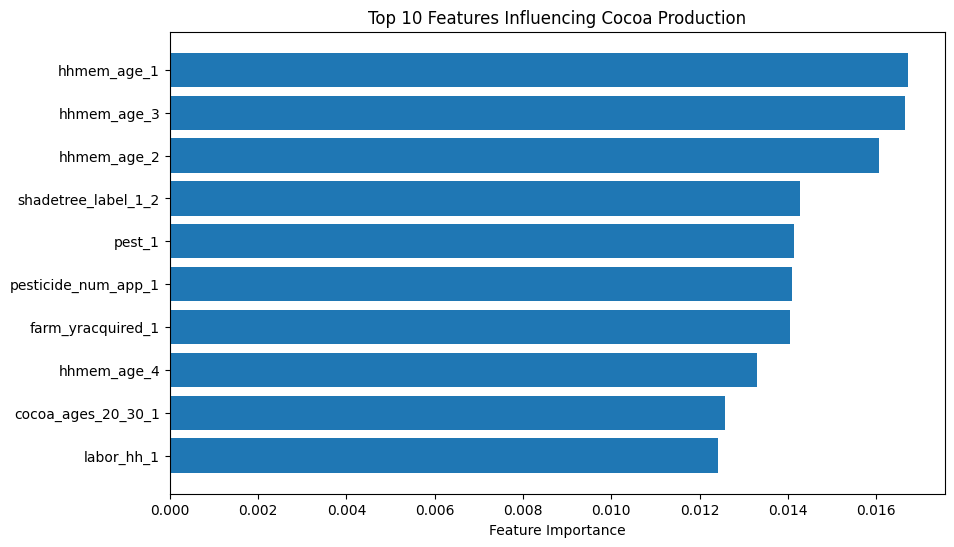

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load the reduced dataset
df = pd.read_csv("reduced_dataset.csv")

# Drop columns that are not relevant
columns_to_drop = ["Unnamed: 0", "today"]
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

# Assume the target variable is 'cocoa_produce'
target = 'cocoa_produce'
X = df.drop(columns=[target])
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Fit a Random Forest Regressor with parallel processing
rfr = RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1)
rfr.fit(X_train, y_train)

# Get feature importances from the model
importances = rfr.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Optionally, plot the top 10 features
top_n = 10
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:top_n], importance_df['Importance'][:top_n])
plt.xlabel("Feature Importance")
plt.title("Top 10 Features Influencing Cocoa Production")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()


In [6]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the reduced dataset (make sure it contains 'cocoa_produce')
df_ols = pd.read_csv("reduced_dataset.csv")

# Optional: Drop columns like 'Unnamed: 0' if they exist
if "Unnamed: 0" in df_ols.columns:
    df_ols.drop(columns=["Unnamed: 0"], inplace=True)

# 2. Define the target and features
target = "cocoa_produce"
X = df_ols.drop(columns=[target])
y = df_ols[target]

# 3. Add a constant for the OLS intercept
X = sm.add_constant(X)

# 4. Fit the OLS model
model = sm.OLS(y, X).fit()

# 5. Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          cocoa_produce   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.185
Date:                Sun, 02 Mar 2025   Prob (F-statistic):             0.0603
Time:                        02:26:25   Log-Likelihood:                -8860.8
No. Observations:                1505   AIC:                         1.807e+04
Df Residuals:                    1329   BIC:                         1.901e+04
Df Model:                         175                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     